In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
cols = ["age", "workclass", "fnlwgt", "education", "education_num", 
        "marital_status", "occupation", "relationship", "race", "sex",
        "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"]
df = pd.read_csv(url, names=cols, skipinitialspace=True)

df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
(32561, 15)
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
cap

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


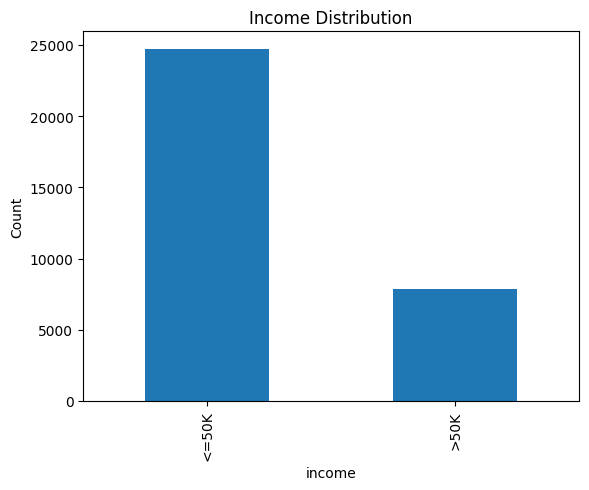

In [2]:
df['income'].value_counts().plot(kind='bar')
plt.title('Income Distribution')
plt.ylabel('Count')
plt.show()

Substantially more individuals have an income that is equal to or less than 50,000 USD compared to those with more than 50k annually.

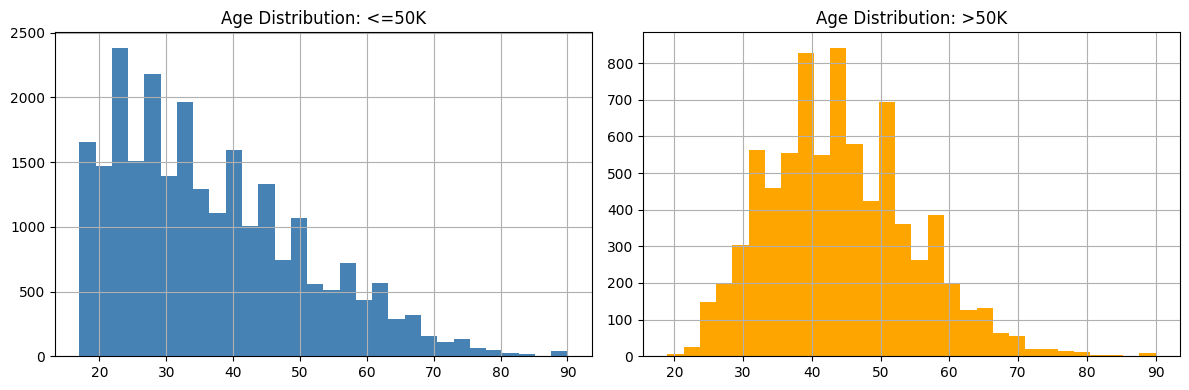

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['income'] == '<=50K']['age'].hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution: <=50K')

df[df['income'] == '>50K']['age'].hist(bins=30, ax=axes[1], color='orange')
axes[1].set_title('Age Distribution: >50K')

plt.tight_layout()
plt.show()

Younger people tend to be more likely to earn <= 50K than older people.

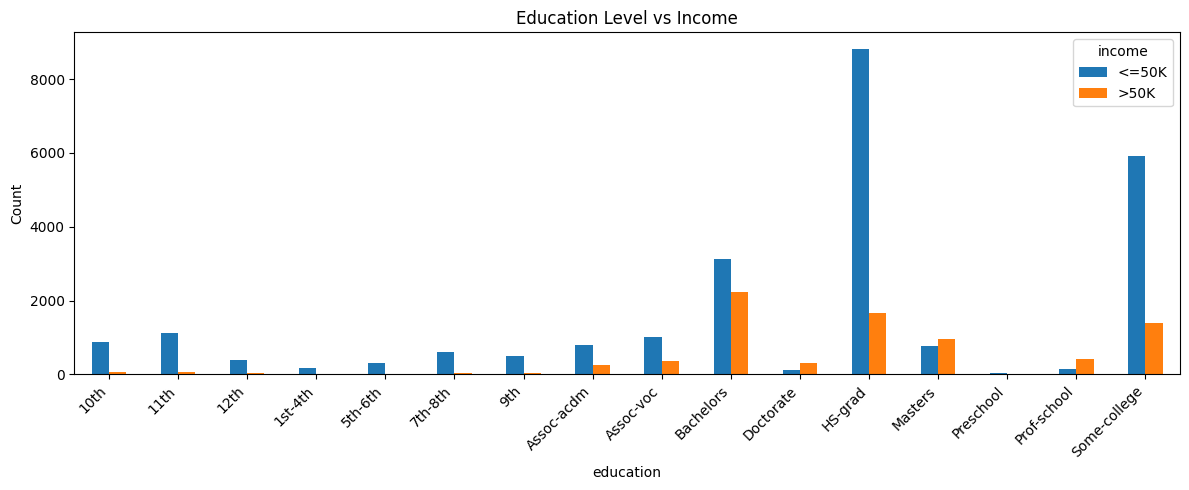

In [4]:
edu_income = df.groupby(['education', 'income']).size().unstack()
edu_income.plot(kind='bar', figsize=(12, 5))
plt.title('Education Level vs Income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Education level is directly correlated with income, with degree holders being substantially more likely to earn more than 50,000 a year compared to HS grads.

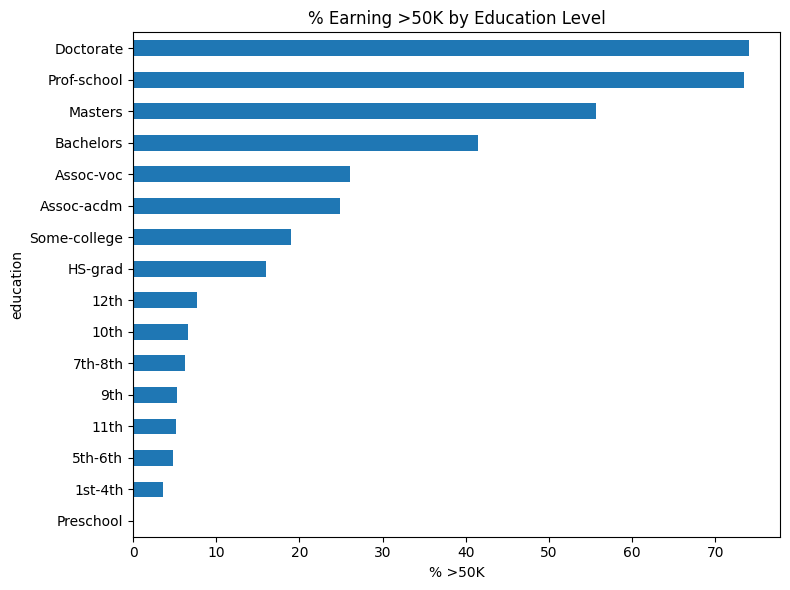

In [5]:
edu_pct = df.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values()

edu_pct.plot(kind='barh', figsize=(8, 6))
plt.title('% Earning >50K by Education Level')
plt.xlabel('% >50K')
plt.tight_layout()
plt.show()